In [32]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE, Isomap, MDS
import umap
import matplotlib.patches as mpatches
from scipy.stats import entropy
from sklearn.decomposition import LatentDirichletAllocation

In [33]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_SYMBOLIC = PROJECT_ROOT / "data" / "symbolic"
DATA_SYMBOLIC.mkdir(parents=True, exist_ok=True)

DATA_CLUSTER = PROJECT_ROOT / "data" / "cluster"
DATA_CLUSTER.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", DATA_CLUSTER)

Processed data folder: c:\Users\ccana\Documents\Doutorado\VISEMTracking\data\cluster


In [34]:
df_processed = pd.read_csv(DATA_SYMBOLIC / "01_symbolic.csv")
df = pd.read_csv(DATA_SYMBOLIC / "02_symbolic_per_trajectory.csv")

In [35]:
n = 10

def parse_symbolic(s):
    try:
        return ast.literal_eval(s)
    except:
        return []

df['movement_list'] = df[f"symbolic_movement_{n}"].apply(parse_symbolic)
df['movement_list'] = df['movement_list'].apply(
    lambda seq: [s for s in seq if s != '']
)

Identificação dos Estados Únicos

In [36]:
all_states = set()
for seq in df['movement_list']:
    all_states.update(seq)

unique_states = sorted(list(all_states))
state_to_idx = {state: i for i, state in enumerate(unique_states)}
n_states = len(unique_states)
print(f"Número de estados identificados: {n_states}")


Número de estados identificados: 20


Cálculo da Matriz de Markov por Trajetória

In [37]:
transition_matrices = []
markov_matrices = []

for seq in df['movement_list']:
    # Inicializa matriz de contagem
    matrix = np.zeros((n_states, n_states))
    
    # Contagem de transições
    if len(seq) > 1:
        for i in range(len(seq) - 1):
            current_state = seq[i]
            next_state = seq[i+1]
            r = state_to_idx[current_state]
            c = state_to_idx[next_state]
            matrix[r, c] += 1
            
    # Normalização (Contagem -> Probabilidade)
    row_sums = matrix.sum(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        prob_matrix = matrix / row_sums[:, np.newaxis]
    prob_matrix = np.nan_to_num(prob_matrix) # Trata divisões por zero
    
    # Linearização para vetor de características
    transition_matrices.append(prob_matrix.flatten())
    markov_matrices.append(prob_matrix)
X = np.array(transition_matrices)

In [38]:
N_STATES = 20  # número de estados
N_TOPICS = 5                                # ajuste depois
SCALE = 100                                 # pseudo-contagens
RANDOM_STATE = 42


In [40]:
docs_A = []

for states in all_states:
    doc = np.zeros(N_STATES * N_STATES, dtype=int)
    
    for t in range(len(states) - 1):
        i = int(states[t])
        j = int(states[t + 1])
        
        # proteção extra
        if 0 <= i < N_STATES and 0 <= j < N_STATES:
            word_id = i * N_STATES + j
            doc[word_id] += 1
    
    docs_A.append(doc)

X_lda_A = np.vstack(docs_A)


ValueError: invalid literal for int() with base 10: 'M'

In [ ]:
# número de transições por trajetória
X_lda_A.sum(axis=1)[:10]


array([100, 100,  98, 100, 102, 100,  99,  99,  99, 101])

In [ ]:
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    learning_method='batch',
    random_state=RANDOM_STATE
)

theta = lda.fit_transform(X_lda)

theta.shape


(807, 5)

In [ ]:
phi = lda.components_

# normalizar para distribuição de probabilidade
phi = phi / phi.sum(axis=1, keepdims=True)

phi.shape


(5, 400)

In [ ]:
topic_transition_matrices = []

for k in range(N_TOPICS):
    topic_matrix = phi[k].reshape(N_STATES, N_STATES)
    topic_transition_matrices.append(topic_matrix)


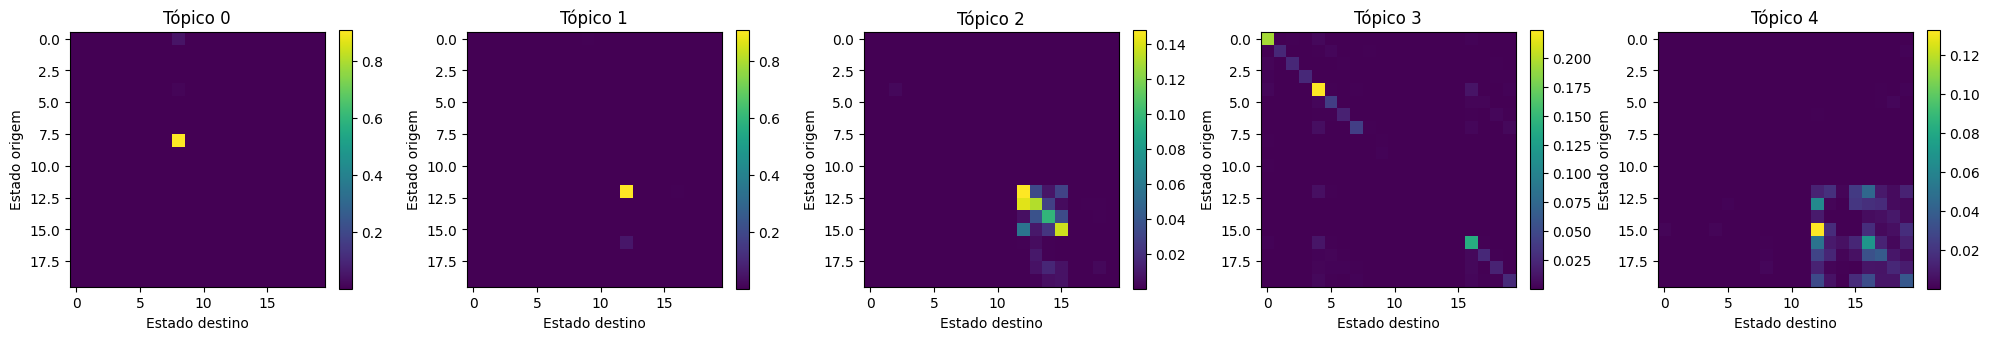

In [ ]:
fig, axes = plt.subplots(1, N_TOPICS, figsize=(4 * N_TOPICS, 4))

for k, ax in enumerate(axes):
    im = ax.imshow(topic_transition_matrices[k])
    ax.set_title(f"Tópico {k}")
    ax.set_xlabel("Estado destino")
    ax.set_ylabel("Estado origem")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()
